In [5]:
!pip install imbalanced-learn
#installing required libraries

In [6]:
#importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression # Added this import
from sklearn.metrics import (
accuracy_score,
precision_score,
recall_score,
f1_score,
confusion_matrix,
classification_report,
roc_auc_score,
roc_curve
)

In [7]:
df = pd.read_csv('/content/creditcard.csv')

df.head()
df.shape
df.info()
#dispaying dataset



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 124861 entries, 0 to 124860
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    124861 non-null  int64  
 1   V1      124861 non-null  float64
 2   V2      124861 non-null  float64
 3   V3      124861 non-null  float64
 4   V4      124860 non-null  float64
 5   V5      124860 non-null  float64
 6   V6      124860 non-null  float64
 7   V7      124860 non-null  float64
 8   V8      124860 non-null  float64
 9   V9      124860 non-null  float64
 10  V10     124860 non-null  float64
 11  V11     124860 non-null  float64
 12  V12     124860 non-null  float64
 13  V13     124860 non-null  float64
 14  V14     124860 non-null  float64
 15  V15     124860 non-null  float64
 16  V16     124860 non-null  float64
 17  V17     124860 non-null  float64
 18  V18     124860 non-null  float64
 19  V19     124860 non-null  float64
 20  V20     124860 non-null  float64
 21  V21     12

In [8]:
df.isnull().sum()
#checking missing values

,0
Time,0
V1,0
V2,0
V3,0
V4,1
V5,1
V6,1
V7,1
V8,1
V9,1


In [9]:
print("Duplicates:", df.duplicated().sum())
#checking duplicate values
df = df.drop_duplicates() #Removing duplicates
print(df.shape)



Duplicates: 477
(124384, 31)


Explanatory Data Analysis:

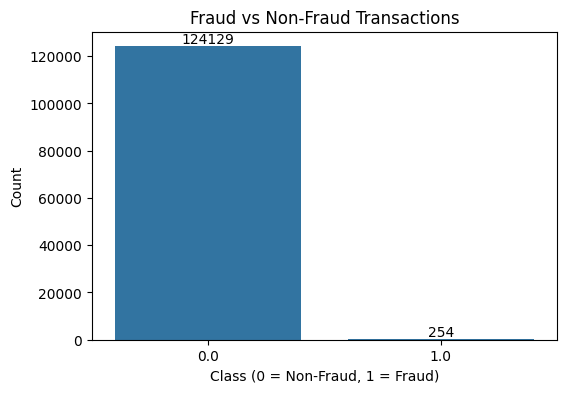

In [10]:
plt.figure(figsize=(6,4))

ax = sns.countplot(x='Class', data=df)

plt.title('Fraud vs Non-Fraud Transactions')
plt.xlabel('Class (0 = Non-Fraud, 1 = Fraud)')
plt.ylabel('Count')

# Add values on bars
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width()/2., p.get_height()),
                ha='center', va='bottom')

plt.show()

In [11]:
#Fraud Percentage
fraud = len(df[df['Class'] == 1])
normal = len(df[df['Class'] == 0])

print("Fraud Transactions:", fraud)
print("Normal Transactions:", normal)

print("Fraud Percentage:",
      round((fraud/len(df))*100,4), "%")

Fraud Transactions: 254
Normal Transactions: 124129
Fraud Percentage: 0.2042 %


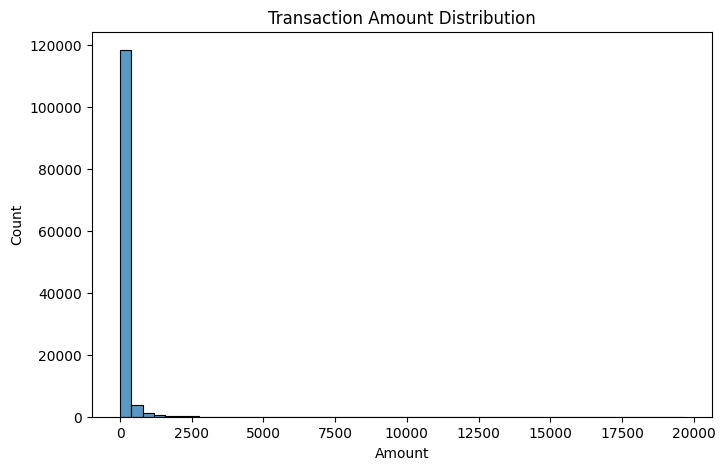

In [12]:
#distrbuting amount
plt.figure(figsize=(8,5))
sns.histplot(df['Amount'], bins=50)
plt.title("Transaction Amount Distribution")
plt.show()

Correlation Matrix

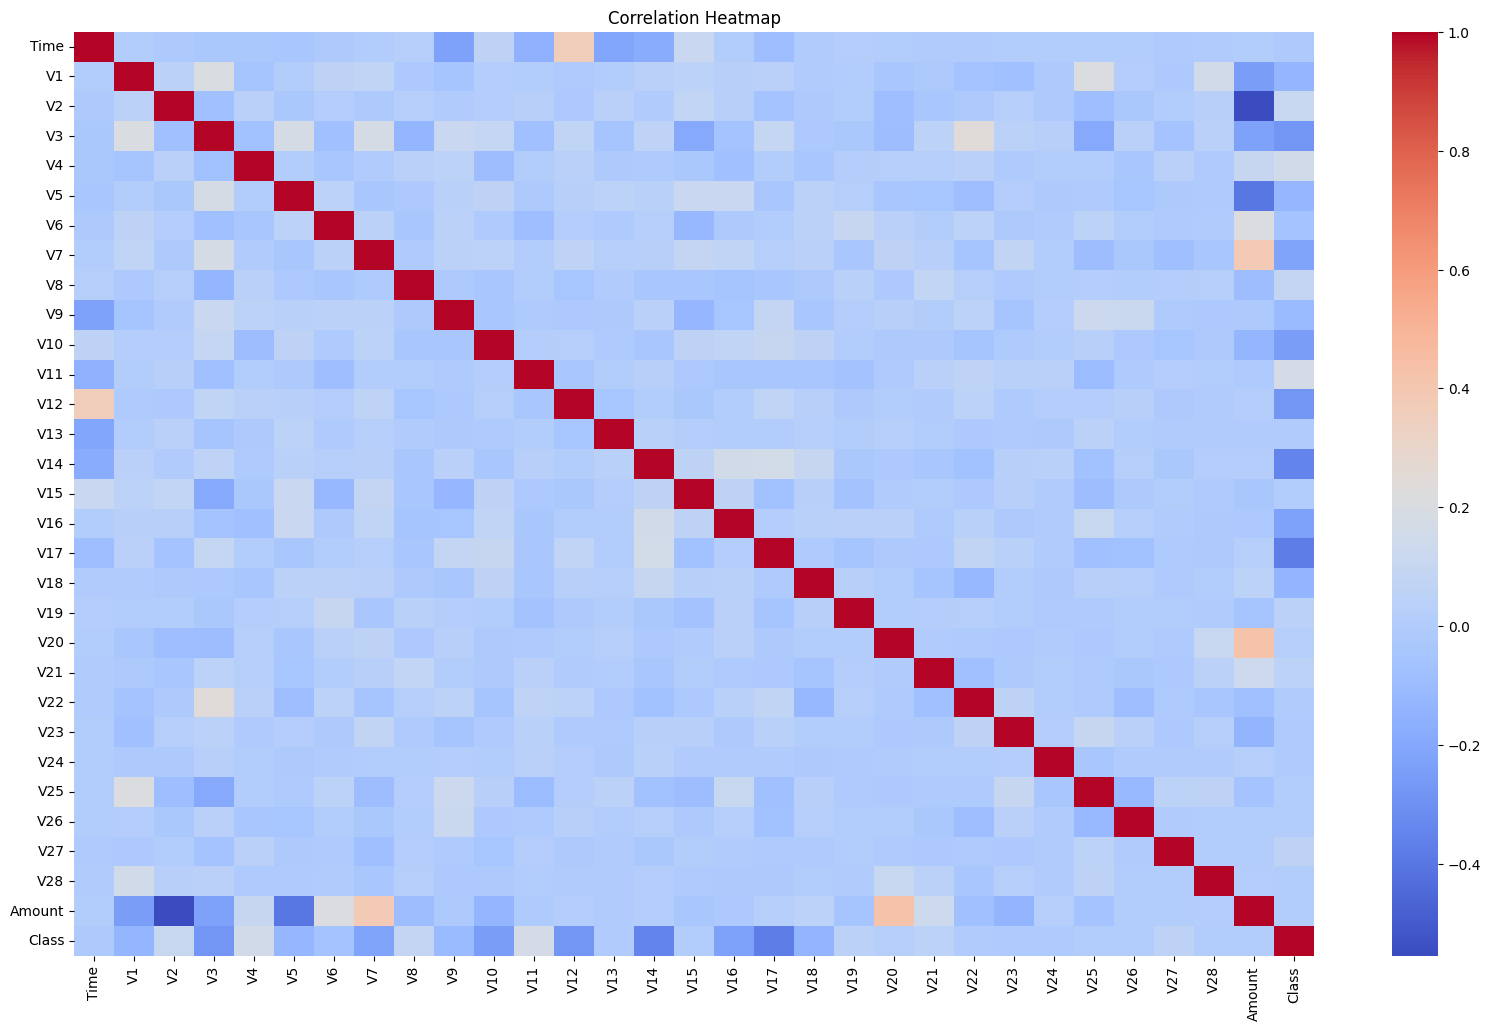

In [13]:
plt.figure(figsize=(20,12))

sns.heatmap(df.corr(), cmap='coolwarm')

plt.title("Correlation Heatmap")

plt.show()

In [14]:
scaler = StandardScaler()
df['scaled_amount'] = scaler.fit_transform(
df['Amount'].values.reshape(-1,1)
)
df['scaled_time'] = scaler.fit_transform(
df['Time'].values.reshape(-1,1)
)
#scaling amount and time
df.drop(['Amount','Time'], axis=1, inplace=True)

In [15]:
X = df.drop('Class', axis=1)
y = df['Class']
#seperating features and target

In [16]:
import numpy as np

# Identify and drop rows where 'y' contains NaN values
# This is necessary because train_test_split with stratify=y cannot handle NaN in the target variable.
valid_indices = y.dropna().index
X = X.loc[valid_indices]
y = y.loc[valid_indices]


In [17]:
smote = SMOTE(random_state=42)

X_resampled, y_resampled = smote.fit_resample(X, y)

print("Before SMOTE:")
print(y.value_counts())

print("\nAfter SMOTE:")
print(y_resampled.value_counts())

Before SMOTE:
Class
0.0    124129
1.0       254
Name: count, dtype: int64

After SMOTE:
Class
0.0    124129
1.0    124129
Name: count, dtype: int64


In [18]:
#Splitting daata sets
X_train, X_test, y_train, y_test = train_test_split(
    X_resampled,
    y_resampled,
    test_size=0.2,
    random_state=42
)

print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

Training Data: (198606, 30)
Testing Data: (49652, 30)


In [19]:

#Logistic Regression
lr = LogisticRegression()

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)



In [20]:
#Decision Treee
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)



In [21]:
#Random forest
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

In [22]:
#Model Evaluation
def evaluate_model(name, y_test, predictions):

    print("Model:", name)
    print("-"*40)

    print("Accuracy:",
          accuracy_score(y_test, predictions))

    print("Precision:",
          precision_score(y_test, predictions))

    print("Recall:",
          recall_score(y_test, predictions))

    print("F1 Score:",
          f1_score(y_test, predictions))

    print("ROC AUC:",
          roc_auc_score(y_test, predictions))

    print("\nClassification Report\n")
    print(classification_report(y_test, predictions))

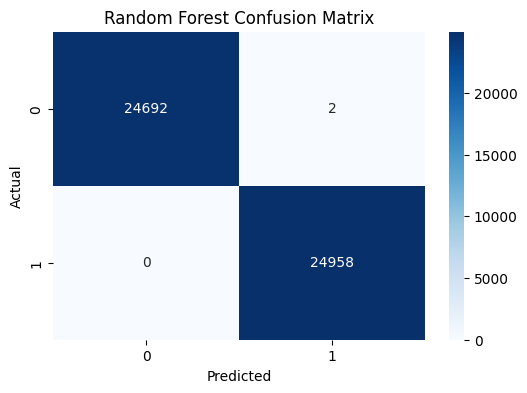

In [26]:
cm = confusion_matrix(y_test, rf_pred)

plt.figure(figsize=(6,4))

sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues')

plt.title('Random Forest Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.show()

In [27]:
results = pd.DataFrame({
    'Model': ['Logistic Regression',
              'Decision Tree',
              'Random Forest'],

    'Accuracy': [
        accuracy_score(y_test, lr_pred),
        accuracy_score(y_test, dt_pred),
        accuracy_score(y_test, rf_pred)
    ],

    'Precision': [
        precision_score(y_test, lr_pred),
        precision_score(y_test, dt_pred),
        precision_score(y_test, rf_pred)
    ],

    'Recall': [
        recall_score(y_test, lr_pred),
        recall_score(y_test, dt_pred),
        recall_score(y_test, rf_pred)
    ],

    'F1 Score': [
        f1_score(y_test, lr_pred),
        f1_score(y_test, dt_pred),
        f1_score(y_test, rf_pred)
    ]
})

results.sort_values(by='F1 Score',
                    ascending=False)

,Model,Accuracy,Precision,Recall,F1 Score
2,Random Forest,0.999960,0.999920,1.000000,0.999960
1,Decision Tree,0.998308,0.997480,0.999159,0.998319
0,Logistic Regression,0.955087,0.976558,0.933048,0.954307


In [25]:
import pickle

pickle.dump(rf,
            open('fraud_model.pkl', 'wb'))

print("Model Saved Successfully")

Model Saved Successfully


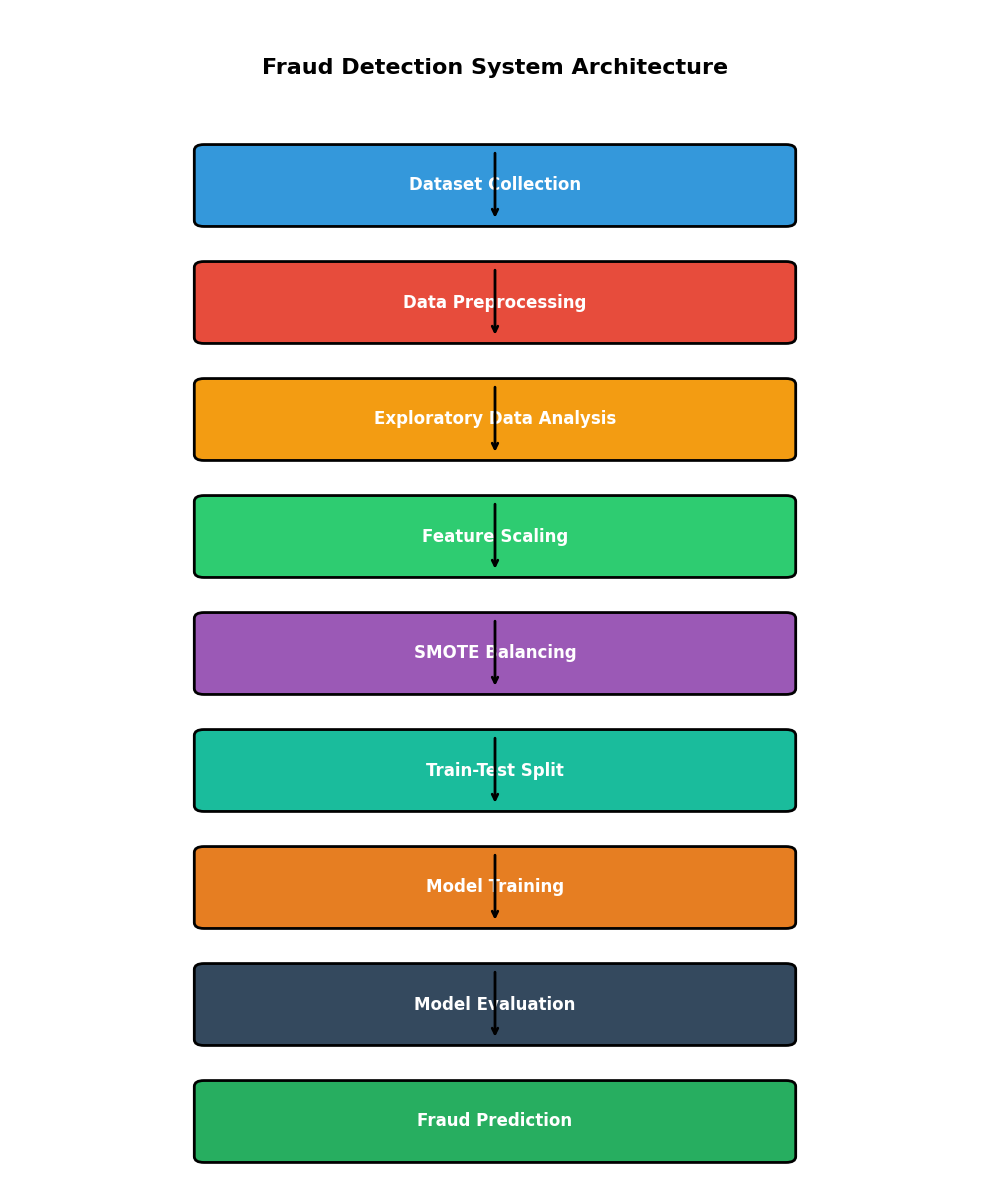

In [28]:
##Draw for system architecture:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.patches import FancyBboxPatch

fig, ax = plt.subplots(figsize=(10, 12))
ax.set_xlim(0, 10)
ax.set_ylim(0, 20)
ax.axis('off')

# Title
ax.text(5, 19, 'Fraud Detection System Architecture',
        fontsize=16, fontweight='bold', ha='center', va='center')

steps = [
    'Dataset Collection',
    'Data Preprocessing',
    'Exploratory Data Analysis',
    'Feature Scaling',
    'SMOTE Balancing',
    'Train-Test Split',
    'Model Training',
    'Model Evaluation',
    'Fraud Prediction'
]

colors = ['#3498db', '#e74c3c', '#f39c12', '#2ecc71', '#9b59b6',
          '#1abc9c', '#e67e22', '#34495e', '#27ae60']

y_positions = list(range(17, 0, -2))

for i, (step, color) in enumerate(zip(steps, colors)):
    y = y_positions[i]
    # Draw box
    box = FancyBboxPatch((2, y-0.6), 6, 1.2,
                         boxstyle="round,pad=0.1",
                         facecolor=color,
                         edgecolor='black',
                         linewidth=2)
    ax.add_patch(box)
    ax.text(5, y, step, fontsize=12, fontweight='bold',
            ha='center', va='center', color='white')

    # Draw arrow
    if i < len(steps) - 1:
        ax.annotate('', xy=(5, y-0.6), xytext=(5, y+0.6),
                   arrowprops=dict(arrowstyle='->',
                                 lw=2,
                                 color='black'))

plt.tight_layout()
plt.show()